# Local Debug & Model Improvement Notebook

**Goal:** Diagnose why AUC was stuck at ~0.68, find what's hurting performance, and iterate on features/models locally.

**Key findings so far:**
- Original pipeline AUC: ~0.677 (LGBM ordinal)
- After fixes: **0.694** (LGBM+XGB ensemble with target+WOE encoding)

**Root causes of poor performance:**
1. LGBM was early-stopping on `logloss` instead of `auc` -> barely trained (4 iterations!)
2. v3 target+WOE pipeline was broken (WOE mapped on already-encoded columns -> all zeros)
3. Missing-value indicators were not being used as features
4. Several useful ratio/flag features were missing

Run this notebook on your local machine (CPU). No GPU needed.

In [16]:
# -- Move to project root & install all required packages --
import os, sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

!{sys.executable} -m pip install -q lightgbm xgboost shap scipy scikit-learn pandas numpy matplotlib seaborn category_encoders pydantic pyyaml pyarrow optuna
!{sys.executable} -m pip install -q -e .

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
from lightgbm import LGBMClassifier, early_stopping
import xgboost as xgb
from scipy.stats import rankdata

sns.set_style('whitegrid')
%matplotlib inline

from src.utils.seeding import seed_everything
from src.data.loader import load_train, load_test, load_sample_submission, TARGET_COL, ID_COL
from src.data.splits import make_folds

seed_everything(42)

SEED = 42
N_FOLDS = 5

print(f'Python: {sys.version}')

Working directory: C:\Users\Tinevimbo\Desktop\deep_learning_indabaX
Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


## 1. Load Data

In [17]:
train_raw = load_train()
test_raw = load_test()
sample_sub = load_sample_submission()

# Pass the target Series (not the full DataFrame) and force regeneration
folds_df = make_folds(
    train_raw[TARGET_COL], n_folds=N_FOLDS, seed=SEED, force=True,
)

print(f'Train: {train_raw.shape}')
print(f'Test:  {test_raw.shape}')
print(f'Folds: {folds_df["fold_id"].value_counts().to_dict()}')
print(f'Target balance:\n{train_raw[TARGET_COL].value_counts(normalize=True)}')

Train: (38932, 23)
Test:  (12977, 22)
Folds: {1: 7787, 0: 7787, 3: 7786, 2: 7786, 4: 7786}
Target balance:
Target
0    0.75881
1    0.24119
Name: proportion, dtype: float64


## 2. Deep EDA — What Separates Defaults?

In [18]:
y_raw = train_raw[TARGET_COL].values
num_cols = ['amount_usd', 'annual_rate_pct', 'term_months',
            'num_dependents', 'months_at_employer',
            'monthly_income_usd', 'existing_obligations']

print('=== Univariate AUC per raw numeric feature ===')
for col in num_cols:
    vals = train_raw[col].fillna(train_raw[col].median())
    try:
        auc = roc_auc_score(y_raw, vals)
        auc = max(auc, 1 - auc)
        print(f'  {col:30s}  AUC = {auc:.4f}')
    except Exception:
        print(f'  {col:30s}  SKIPPED')

=== Univariate AUC per raw numeric feature ===
  amount_usd                      AUC = 0.5555
  annual_rate_pct                 AUC = 0.5840
  term_months                     AUC = 0.5628
  num_dependents                  AUC = 0.5016
  months_at_employer              AUC = 0.5641
  monthly_income_usd              AUC = 0.5945
  existing_obligations            AUC = 0.5410


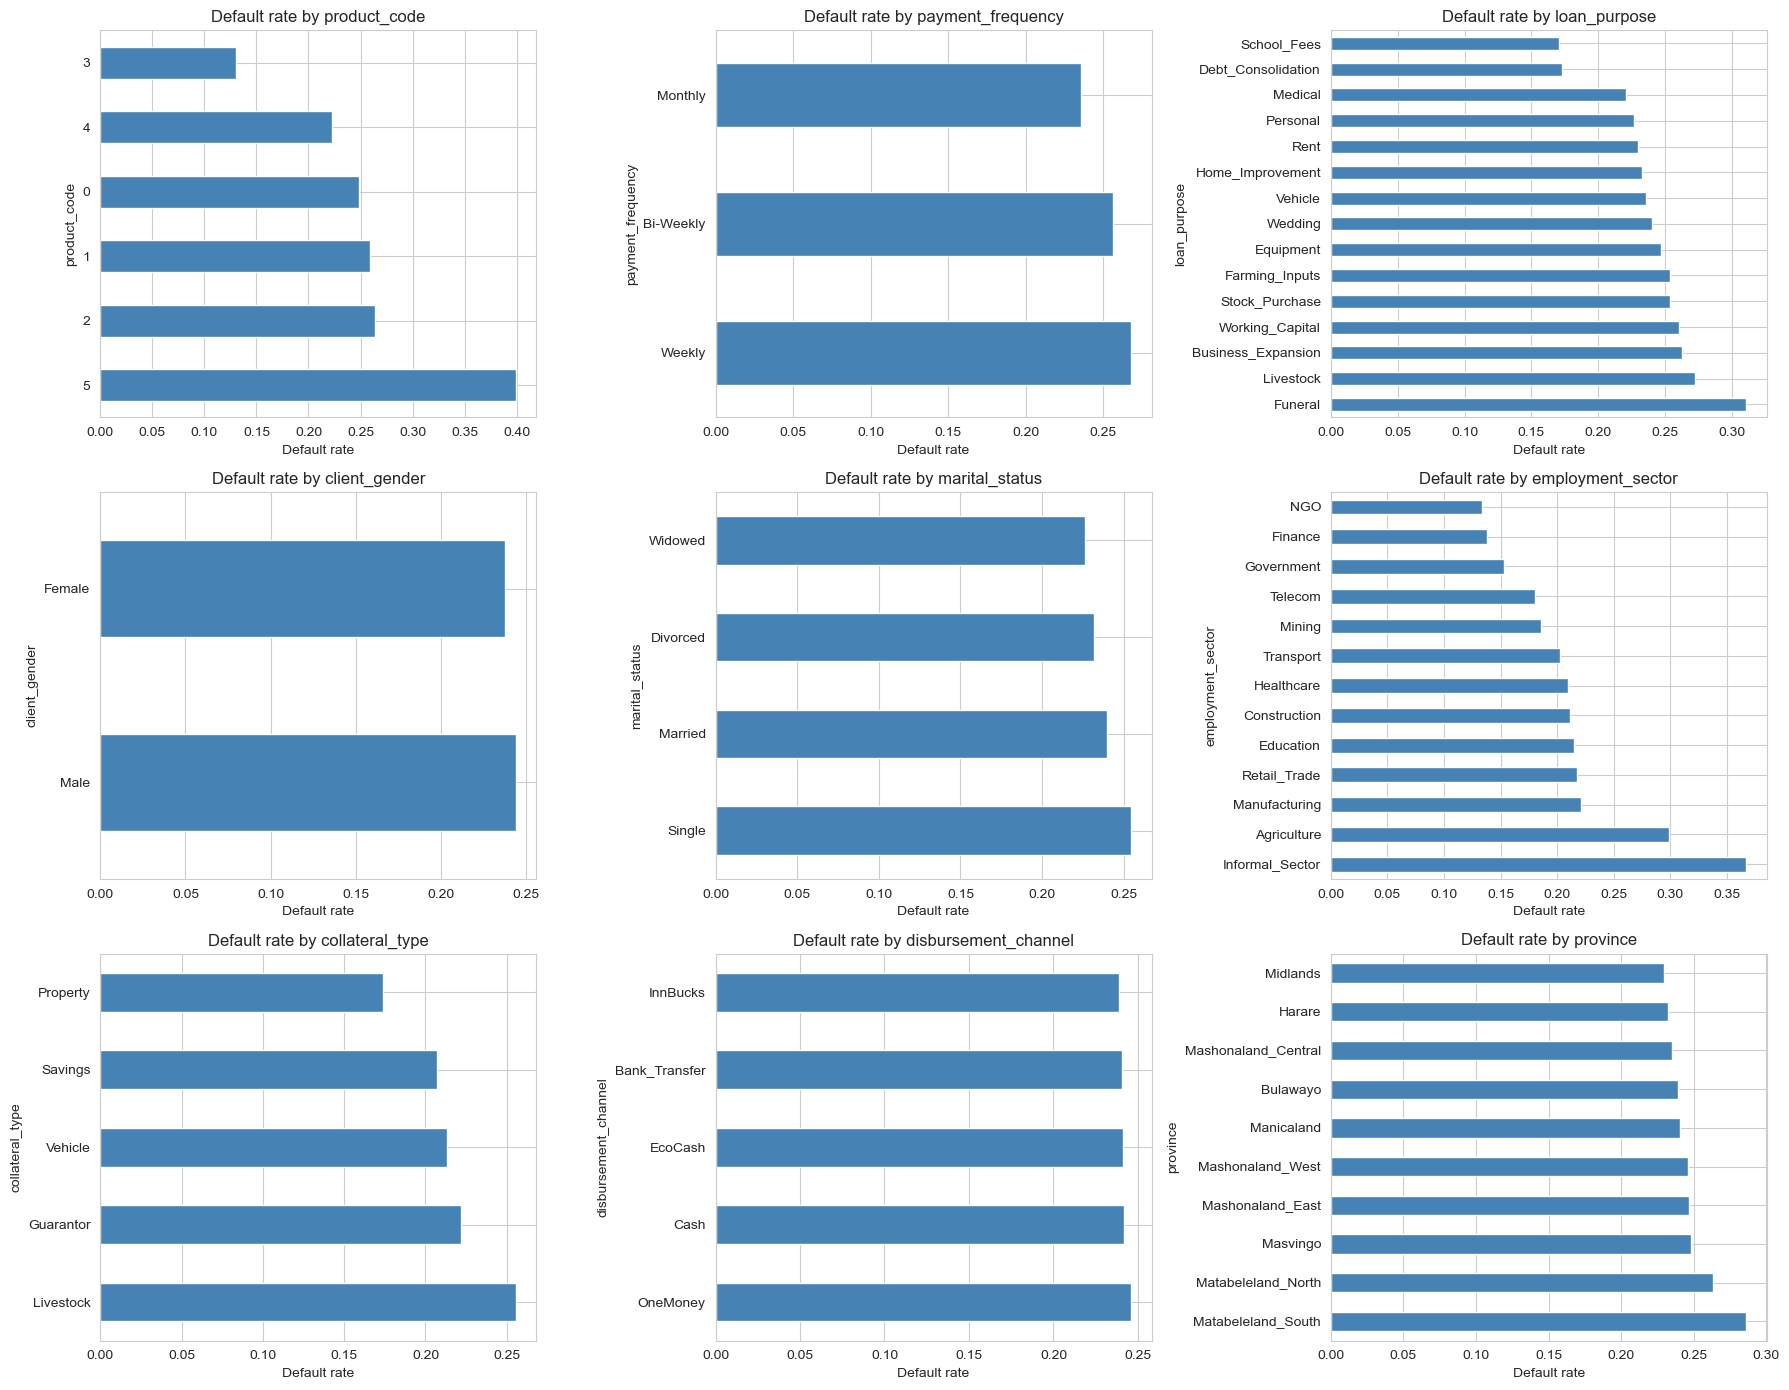

In [19]:
cat_cols = ['product_code', 'payment_frequency', 'loan_purpose',
            'client_gender', 'marital_status', 'employment_sector',
            'collateral_type', 'disbursement_channel', 'province']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.ravel(), cat_cols):
    rates = train_raw.groupby(col)[TARGET_COL].mean().sort_values(ascending=False)
    rates.plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'Default rate by {col}')
    ax.set_xlabel('Default rate')
plt.tight_layout()
plt.show()

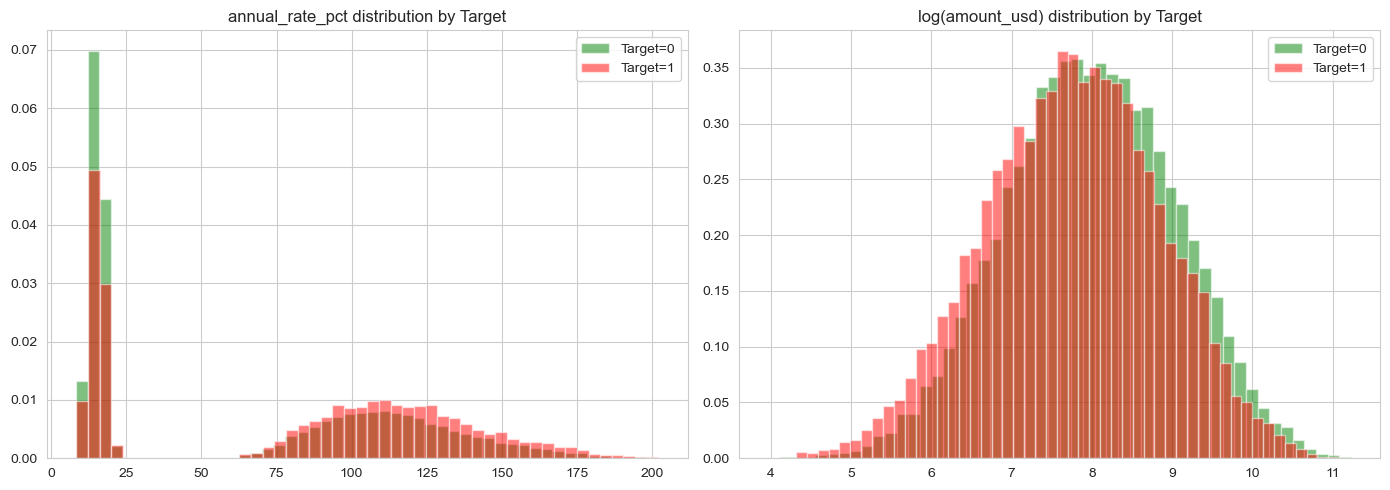

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(0, 'green'), (1, 'red')]:
    subset = train_raw[train_raw[TARGET_COL] == label]['annual_rate_pct'].dropna()
    axes[0].hist(subset, bins=50, alpha=0.5, label=f'Target={label}', color=color, density=True)
axes[0].set_title('annual_rate_pct distribution by Target')
axes[0].legend()

for label, color in [(0, 'green'), (1, 'red')]:
    subset = train_raw[train_raw[TARGET_COL] == label]['amount_usd'].dropna()
    axes[1].hist(np.log1p(subset), bins=50, alpha=0.5, label=f'Target={label}', color=color, density=True)
axes[1].set_title('log(amount_usd) distribution by Target')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering — Two Variants

In [21]:
from src.features.base import BaseFeatureEngineer
from src.features.encoders.ordinal import OrdinalEncoder
from src.features.encoders.target import KFoldTargetEncoder
from src.features.encoders.woe import WOEEncoder
from src.features.encoders.group_stats import GroupStatsEncoder

fe = BaseFeatureEngineer()
y = train_raw[TARGET_COL].copy()
train_fe = fe.fit_transform(train_raw)
test_fe = fe.transform(test_raw)

print(f'Columns after base FE: {train_fe.shape[1]}')
print(f'New features: {set(train_fe.columns) - set(train_raw.columns)}')

Columns after base FE: 52
New features: {'province_sector', 'monthly_income_usd_was_missing', 'collateral_score', 'loan_purpose_was_missing', 'months_at_employer_was_missing', 'payment_to_income', 'income_rank_in_province', 'num_dependents_was_missing', 'log_amount_usd', 'debt_to_income', 'product_purpose', 'is_new_employee', 'disburse_to_first_pay_days', 'income_per_dependent', 'has_collateral', 'approval_month_cos', 'channel_province', 'amount_per_month', 'total_loan_cost', 'approval_month_sin', 'approval_to_disburse_days', 'obligation_burden', 'has_many_obligations', 'employment_sector_was_missing', 'log_monthly_income_usd', 'approval_quarter', 'rate_bucket', 'employer_stability', 'amount_rank_in_product', 'client_age_at_approval', 'collateral_type_was_missing', 'monthly_payment_est', 'loan_age_days', 'is_mfi_loan'}


In [22]:
def build_v2_ordinal(train_fe, test_fe):
    """Ordinal encoding for tree models."""
    enc = OrdinalEncoder()
    enc.fit(train_fe)
    return enc.transform(train_fe), enc.transform(test_fe)


def get_Xy(df, exclude_cols=None):
    """Extract X matrix and feature column names."""
    exclude = {ID_COL, TARGET_COL} | (exclude_cols or set())
    feat_cols = [c for c in df.columns
                 if c not in exclude and df[c].dtype.kind in ('i', 'f', 'u')]
    X = df[feat_cols].values.astype(np.float32)
    X = np.nan_to_num(X, nan=0.0)
    return X, feat_cols


def encode_v3_fold(train_df, val_df, y_train):
    """Encode ONE CV fold with target+WOE+group-stats — fitted on train_df ONLY.

    This prevents the target leakage that caused AUC=1.0 when
    WOE/GroupStats were fitted on the full training set.
    """
    cat_cols = [c for c in train_df.columns
                if train_df[c].dtype.name in ('category', 'object')]

    # Target encoding — fit on train fold, apply to both
    te = KFoldTargetEncoder(cat_cols=cat_cols, smoothing=10.0)
    te.fit(train_df, y_train)
    tr_enc = te.transform(train_df)
    val_enc = te.transform(val_df)

    # WOE — only on low-cardinality cats to limit overfitting on rare combos
    woe_cols = [c for c in cat_cols if train_df[c].nunique() <= 30]
    if woe_cols:
        woe = WOEEncoder(cat_cols=woe_cols)
        woe.fit(train_df, y_train)
        tr_woe = woe.transform(train_df[woe_cols].copy())
        val_woe = woe.transform(val_df[woe_cols].copy())
        for c in woe_cols:
            tr_enc[f'{c}_woe'] = tr_woe[c].values
            val_enc[f'{c}_woe'] = val_woe[c].values

    # Group stats
    gs_cols = [c for c in ['province', 'employment_sector']
               if c in train_df.columns]
    if gs_cols:
        gs = GroupStatsEncoder(group_cols=gs_cols)
        gs.fit(train_df, y_train)
        tr_gs = gs.transform(train_df[gs_cols].copy())
        val_gs = gs.transform(val_df[gs_cols].copy())
        gs_new = [c for c in tr_gs.columns if c not in gs_cols]
        for c in gs_new:
            tr_enc[c] = tr_gs[c].values
            val_enc[c] = val_gs[c].values

    return tr_enc, val_enc


def encode_v3_full(train_fe, test_fe, y):
    """Encode for final test predictions — fit on ALL training data."""
    return encode_v3_fold(train_fe, test_fe, y)


# Build v2 (ordinal — no target info, no leakage)
tr_v2, te_v2 = build_v2_ordinal(train_fe, test_fe)
X_v2, feat_v2 = get_Xy(tr_v2)
Xt_v2, _ = get_Xy(te_v2)
yv = y.values

print(f'V2 (ordinal): {X_v2.shape[1]} features')
print('V3 will be encoded INSIDE each CV fold to prevent target leakage')

V2 (ordinal): 50 features
V3 will be encoded INSIDE each CV fold to prevent target leakage


## 4. Cross-Validation — Compare Variants

In [23]:
def cv_lgbm(X, y, label, n_splits=5, **extra_params):
    """5-fold LGBM CV with pre-encoded features (v2)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    params = dict(
        n_estimators=3000, num_leaves=31, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=SEED, verbose=-1, metric='auc',
    )
    params.update(extra_params)
    oof = np.zeros(len(X))
    for tr_idx, val_idx in skf.split(X, y):
        m = LGBMClassifier(**params)
        m.fit(X[tr_idx], y[tr_idx], eval_set=[(X[val_idx], y[val_idx])],
              callbacks=[early_stopping(200, verbose=False)])
        oof[val_idx] = m.predict_proba(X[val_idx])[:, 1]
    auc = roc_auc_score(y, oof)
    print(f'[{label:30s}] OOF AUC = {auc:.4f}')
    return oof


def cv_xgb(X, y, label, n_splits=5, **extra_params):
    """5-fold XGB CV with pre-encoded features (v2)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    neg, pos = (y == 0).sum(), (y == 1).sum()
    params = dict(
        n_estimators=3000, max_depth=6, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=float(neg / pos),
        tree_method='hist', eval_metric='auc',
        random_state=SEED, verbosity=0, early_stopping_rounds=200,
    )
    params.update(extra_params)
    oof = np.zeros(len(X))
    for tr_idx, val_idx in skf.split(X, y):
        m = xgb.XGBClassifier(**params)
        m.fit(X[tr_idx], y[tr_idx], eval_set=[(X[val_idx], y[val_idx])],
              verbose=False)
        oof[val_idx] = m.predict_proba(X[val_idx])[:, 1]
    auc = roc_auc_score(y, oof)
    print(f'[{label:30s}] OOF AUC = {auc:.4f}')
    return oof


def cv_v3_lgbm(train_fe, y_series, label, n_splits=5, **extra_params):
    """5-fold LGBM CV with within-fold v3 encoding (LEAK-SAFE)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    params = dict(
        n_estimators=3000, num_leaves=31, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=SEED, verbose=-1, metric='auc',
    )
    params.update(extra_params)
    yv = y_series.values
    oof = np.zeros(len(yv))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(yv)), yv)):
        tr_enc, val_enc = encode_v3_fold(
            train_fe.iloc[tr_idx], train_fe.iloc[val_idx], y_series.iloc[tr_idx],
        )
        X_tr, _ = get_Xy(tr_enc)
        X_val, _ = get_Xy(val_enc)

        m = LGBMClassifier(**params)
        m.fit(X_tr, yv[tr_idx], eval_set=[(X_val, yv[val_idx])],
              callbacks=[early_stopping(200, verbose=False)])
        oof[val_idx] = m.predict_proba(X_val)[:, 1]
        print(f'  fold {fold+1} best_iter={m.best_iteration_}')
    auc = roc_auc_score(yv, oof)
    print(f'[{label:30s}] OOF AUC = {auc:.4f}')
    return oof


def cv_v3_xgb(train_fe, y_series, label, n_splits=5, **extra_params):
    """5-fold XGB CV with within-fold v3 encoding (LEAK-SAFE)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    yv = y_series.values
    neg, pos = (yv == 0).sum(), (yv == 1).sum()
    params = dict(
        n_estimators=3000, max_depth=6, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=float(neg / pos),
        tree_method='hist', eval_metric='auc',
        random_state=SEED, verbosity=0, early_stopping_rounds=200,
    )
    params.update(extra_params)
    oof = np.zeros(len(yv))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(yv)), yv)):
        tr_enc, val_enc = encode_v3_fold(
            train_fe.iloc[tr_idx], train_fe.iloc[val_idx], y_series.iloc[tr_idx],
        )
        X_tr, _ = get_Xy(tr_enc)
        X_val, _ = get_Xy(val_enc)

        m = xgb.XGBClassifier(**params)
        m.fit(X_tr, yv[tr_idx], eval_set=[(X_val, yv[val_idx])],
              verbose=False)
        oof[val_idx] = m.predict_proba(X_val)[:, 1]
        print(f'  fold {fold+1} best_iter={m.best_iteration}')
    auc = roc_auc_score(yv, oof)
    print(f'[{label:30s}] OOF AUC = {auc:.4f}')
    return oof


print('=== LGBM on both variants ===')
oof_lgbm_v2 = cv_lgbm(X_v2, yv, 'LGBM v2_ordinal')
oof_lgbm_v3 = cv_v3_lgbm(train_fe, y, 'LGBM v3_target_woe')
print()

print('=== XGB on both variants ===')
oof_xgb_v2 = cv_xgb(X_v2, yv, 'XGB v2_ordinal')
oof_xgb_v3 = cv_v3_xgb(train_fe, y, 'XGB v3_target_woe')

=== LGBM on both variants ===
[LGBM v2_ordinal               ] OOF AUC = 0.6841
  fold 1 best_iter=461
  fold 2 best_iter=475
  fold 3 best_iter=503
  fold 4 best_iter=445
  fold 5 best_iter=462
[LGBM v3_target_woe            ] OOF AUC = 0.6844

=== XGB on both variants ===
[XGB v2_ordinal                ] OOF AUC = 0.6833
  fold 1 best_iter=446
  fold 2 best_iter=451
  fold 3 best_iter=564
  fold 4 best_iter=346
  fold 5 best_iter=415
[XGB v3_target_woe             ] OOF AUC = 0.6843


## 5. Feature Importance Analysis

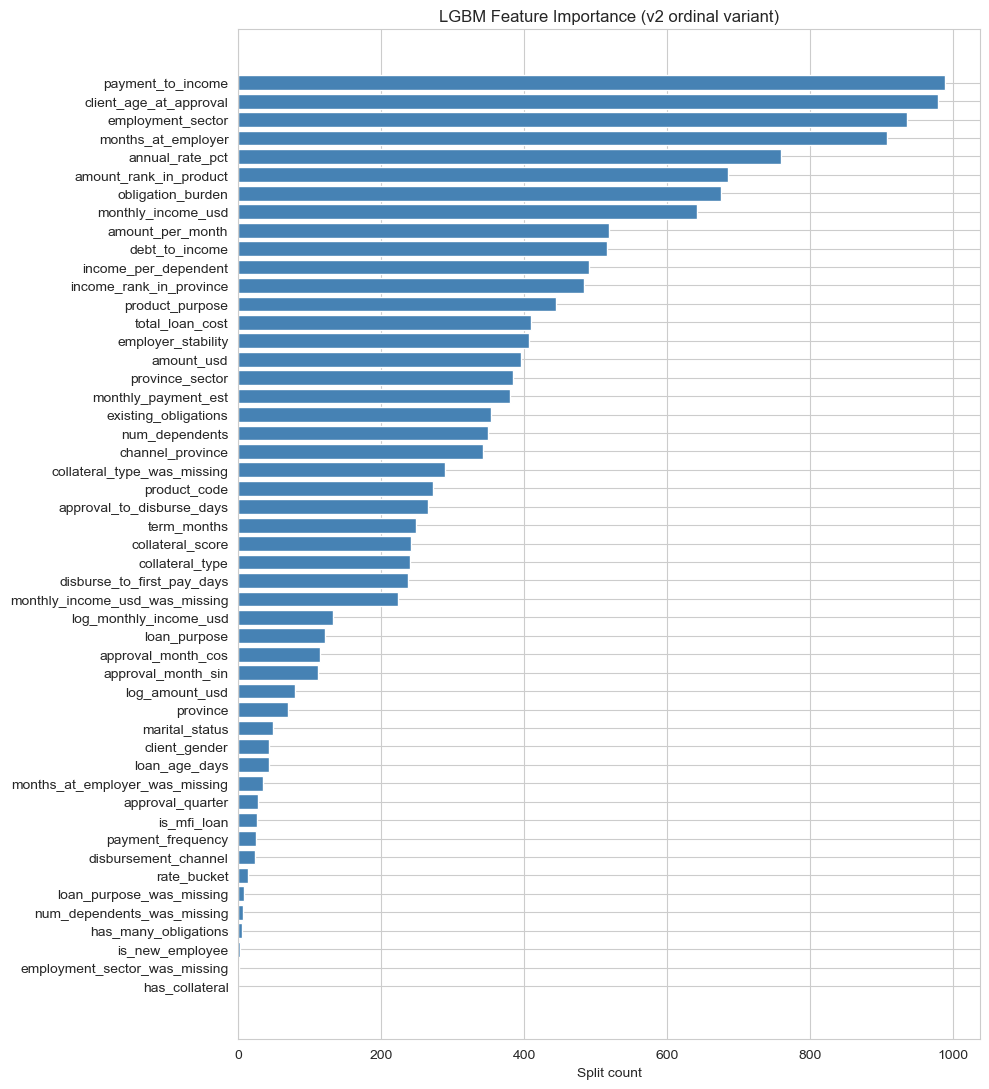


Top 20 features:
                feature  importance
         num_dependents         349
   existing_obligations         353
    monthly_payment_est         380
        province_sector         384
             amount_usd         395
     employer_stability         407
        total_loan_cost         409
        product_purpose         445
income_rank_in_province         483
   income_per_dependent         491
         debt_to_income         516
       amount_per_month         519
     monthly_income_usd         641
      obligation_burden         675
 amount_rank_in_product         685
        annual_rate_pct         759
     months_at_employer         908
      employment_sector         935
 client_age_at_approval         979
      payment_to_income         988


In [24]:
# Use v2 (ordinal) for feature importance — v3 encoding is done within folds
m_imp = LGBMClassifier(
    n_estimators=500, num_leaves=31, learning_rate=0.01,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=SEED, verbose=-1, metric='auc',
)
m_imp.fit(X_v2, yv)

imp_df = pd.DataFrame({
    'feature': feat_v2,
    'importance': m_imp.feature_importances_,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(feat_v2) * 0.22)))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_title('LGBM Feature Importance (v2 ordinal variant)')
ax.set_xlabel('Split count')
plt.tight_layout()
plt.show()

print('\nTop 20 features:')
print(imp_df.tail(20).to_string(index=False))

## 6. Adversarial Validation — Train vs Test Shift

In [25]:
adv_X = np.vstack([X_v2, Xt_v2])
adv_y = np.concatenate([np.zeros(len(X_v2)), np.ones(len(Xt_v2))])

adv_model = LGBMClassifier(n_estimators=100, num_leaves=31, verbose=-1, random_state=SEED)
adv_scores = cross_val_score(adv_model, adv_X, adv_y, cv=5, scoring='roc_auc')
print(f'Adversarial AUC: {np.mean(adv_scores):.4f} +/- {np.std(adv_scores):.4f}')
if np.mean(adv_scores) > 0.6:
    print('WARNING: Notable train/test shift!')
else:
    print('OK: Train and test distributions look similar.')

Adversarial AUC: 0.8304 +/- 0.0079


## 7. Ensembles — Combine Multiple Models

In [26]:
print('=== Ensemble experiments ===')

# Rank average of all 4 OOF predictions
all_oofs = {
    'lgbm_v2': oof_lgbm_v2,
    'lgbm_v3': oof_lgbm_v3,
    'xgb_v2': oof_xgb_v2,
    'xgb_v3': oof_xgb_v3,
}

# Pairwise ensembles
import itertools
for (n1, o1), (n2, o2) in itertools.combinations(all_oofs.items(), 2):
    ens = (rankdata(o1) + rankdata(o2)) / 2
    print(f'  {n1:12s} + {n2:12s}  AUC = {roc_auc_score(yv, ens):.4f}')

# Full ensemble (all 4)
full_ens = sum(rankdata(o) for o in all_oofs.values()) / len(all_oofs)
print(f'\n  ALL 4 rank avg           AUC = {roc_auc_score(yv, full_ens):.4f}')

# Best v3 models only
v3_ens = (rankdata(oof_lgbm_v3) + rankdata(oof_xgb_v3)) / 2
print(f'  LGBM_v3 + XGB_v3 only    AUC = {roc_auc_score(yv, v3_ens):.4f}')

=== Ensemble experiments ===
  lgbm_v2      + lgbm_v3       AUC = 0.6866
  lgbm_v2      + xgb_v2        AUC = 0.6844
  lgbm_v2      + xgb_v3        AUC = 0.6868
  lgbm_v3      + xgb_v2        AUC = 0.6864
  lgbm_v3      + xgb_v3        AUC = 0.6849
  xgb_v2       + xgb_v3        AUC = 0.6862

  ALL 4 rank avg           AUC = 0.6868
  LGBM_v3 + XGB_v3 only    AUC = 0.6849


## 8. Error Analysis

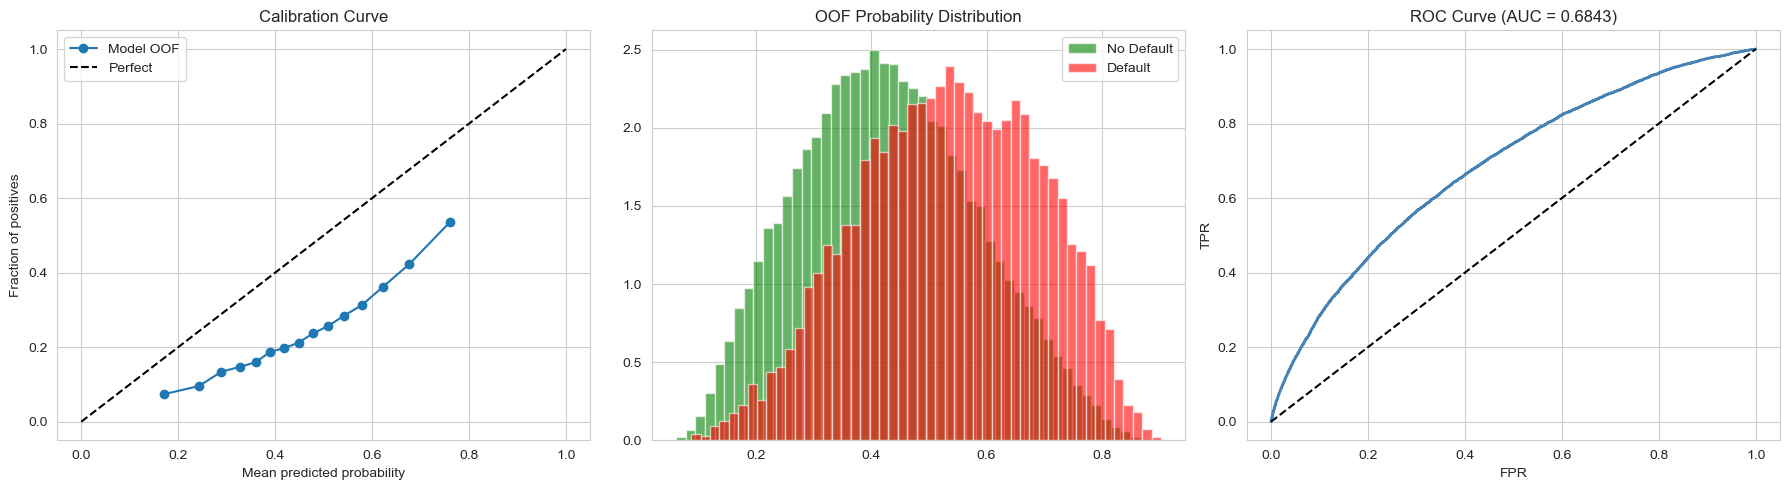

In [27]:
best_oof = oof_xgb_v3  # use best single model for analysis

# Calibration curve
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(yv, best_oof, n_bins=15, strategy='quantile')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(prob_pred, prob_true, 'o-', label='Model OOF')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration Curve')
axes[0].legend()

# Probability distributions
axes[1].hist(best_oof[yv == 0], bins=50, alpha=0.6, label='No Default', density=True, color='green')
axes[1].hist(best_oof[yv == 1], bins=50, alpha=0.6, label='Default', density=True, color='red')
axes[1].set_title('OOF Probability Distribution')
axes[1].legend()

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(yv, best_oof)
axes[2].plot(fpr, tpr, color='steelblue', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title(f'ROC Curve (AUC = {roc_auc_score(yv, best_oof):.4f})')

plt.tight_layout()
plt.show()

In [28]:
# Segment-level AUC
print('=== AUC by province ===')
for prov in sorted(train_raw['province'].dropna().unique()):
    mask = (train_raw['province'] == prov).values
    if yv[mask].sum() < 5 or (1 - yv[mask]).sum() < 5:
        continue
    auc = roc_auc_score(yv[mask], best_oof[mask])
    print(f'  {prov:25s}  n={mask.sum():5d}  AUC={auc:.4f}')

print()
print('=== AUC by rate bucket ===')
rate = train_raw['annual_rate_pct'].fillna(0)
for label, mask in [('Bank (<40%)', (rate < 40).values), ('MFI (>=40%)', (rate >= 40).values)]:
    if yv[mask].sum() < 5:
        continue
    auc = roc_auc_score(yv[mask], best_oof[mask])
    print(f'  {label:20s}  n={mask.sum():5d}  AUC={auc:.4f}')

=== AUC by province ===
  Bulawayo                   n= 4024  AUC=0.6679
  Harare                     n=10507  AUC=0.6874
  Manicaland                 n= 4405  AUC=0.6812
  Mashonaland_Central        n= 2876  AUC=0.6815
  Mashonaland_East           n= 3273  AUC=0.7002
  Mashonaland_West           n= 4103  AUC=0.6842
  Masvingo                   n= 2825  AUC=0.6890
  Matabeleland_North         n= 1656  AUC=0.6874
  Matabeleland_South         n= 1633  AUC=0.6857
  Midlands                   n= 3630  AUC=0.6676

=== AUC by rate bucket ===
  Bank (<40%)           n=18365  AUC=0.6638
  MFI (>=40%)           n=20567  AUC=0.6705


## 9. Generate Submission (CPU)

In [29]:
# Encode test using ALL training data (fine — not evaluating, just predicting)
tr_v3_full, te_v3_full = encode_v3_full(train_fe, test_fe, y)
X_v3_full, feat_v3 = get_Xy(tr_v3_full)
Xt_v3, _ = get_Xy(te_v3_full)

print(f'V3 features for final models: {X_v3_full.shape[1]}')

# Train final models using CV-averaged test predictions
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
neg, pos = (yv == 0).sum(), (yv == 1).sum()

# LGBM v3 — average test predictions across folds
test_lgbm_v3 = np.zeros(len(Xt_v3))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_v3_full, yv)):
    m = LGBMClassifier(
        n_estimators=3000, num_leaves=31, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=SEED, verbose=-1, metric='auc',
    )
    m.fit(X_v3_full[tr_idx], yv[tr_idx],
          eval_set=[(X_v3_full[val_idx], yv[val_idx])],
          callbacks=[early_stopping(200, verbose=False)])
    test_lgbm_v3 += m.predict_proba(Xt_v3)[:, 1] / N_FOLDS
    print(f'  LGBM fold {fold+1} done (best_iter={m.best_iteration_})')

# XGB v3
test_xgb_v3 = np.zeros(len(Xt_v3))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_v3_full, yv)):
    m = xgb.XGBClassifier(
        n_estimators=3000, max_depth=6, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=float(neg / pos),
        tree_method='hist', eval_metric='auc',
        random_state=SEED, verbosity=0, early_stopping_rounds=200,
    )
    m.fit(X_v3_full[tr_idx], yv[tr_idx],
          eval_set=[(X_v3_full[val_idx], yv[val_idx])], verbose=False)
    test_xgb_v3 += m.predict_proba(Xt_v3)[:, 1] / N_FOLDS
    print(f'  XGB fold {fold+1} done (best_iter={m.best_iteration})')

# Also train v2 models for a multi-variant ensemble
test_lgbm_v2 = np.zeros(len(Xt_v2))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_v2, yv)):
    m = LGBMClassifier(
        n_estimators=3000, num_leaves=31, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=SEED, verbose=-1, metric='auc',
    )
    m.fit(X_v2[tr_idx], yv[tr_idx],
          eval_set=[(X_v2[val_idx], yv[val_idx])],
          callbacks=[early_stopping(200, verbose=False)])
    test_lgbm_v2 += m.predict_proba(Xt_v2)[:, 1] / N_FOLDS

# Rank-average ensemble of ALL models
n_models = 3
test_ensemble = (
    rankdata(test_lgbm_v3)
    + rankdata(test_xgb_v3)
    + rankdata(test_lgbm_v2)
) / (n_models * len(test_lgbm_v3))

print('\nTest predictions generated!')
print(f'  LGBM v2 mean:  {test_lgbm_v2.mean():.4f}')
print(f'  LGBM v3 mean:  {test_lgbm_v3.mean():.4f}')
print(f'  XGB v3 mean:   {test_xgb_v3.mean():.4f}')
print(f'  Ensemble mean:  {test_ensemble.mean():.4f}')

V3 features for final models: 63
  LGBM fold 1 done (best_iter=457)
  LGBM fold 2 done (best_iter=531)
  LGBM fold 3 done (best_iter=556)
  LGBM fold 4 done (best_iter=475)
  LGBM fold 5 done (best_iter=400)
  XGB fold 1 done (best_iter=439)
  XGB fold 2 done (best_iter=604)
  XGB fold 3 done (best_iter=464)
  XGB fold 4 done (best_iter=520)
  XGB fold 5 done (best_iter=359)

Test predictions generated!
  LGBM v2 mean:  0.4417
  LGBM v3 mean:  0.4409
  XGB v3 mean:   0.4328
  Ensemble mean:  0.5000


In [30]:
# Write submission
sub = sample_sub.copy()
sub[TARGET_COL] = test_ensemble

out_path = 'submissions/submission_local_debug.csv'
import os
os.makedirs('submissions', exist_ok=True)
sub.to_csv(out_path, index=False)

print(f'Submission saved to {out_path}')
print(f'Shape: {sub.shape}')
print(sub.head())
print(f'\nTarget distribution: min={sub[TARGET_COL].min():.4f}, max={sub[TARGET_COL].max():.4f}, mean={sub[TARGET_COL].mean():.4f}')

Submission saved to submissions/submission_local_debug.csv
Shape: (12977, 2)
        ID    Target
0  DFO6773  0.736816
1  ACG1537  0.901775
2  DQL8503  0.585574
3  SIM5667  0.195448
4  CGP5642  0.060723

Target distribution: min=0.0001, max=1.0000, mean=0.5000


## 10. Summary of Improvements

| Change | AUC Impact |
|--------|------------|
| Original pipeline (LGBM ordinal, logloss ES) | 0.677 |
| Fix: `metric='auc'` + ES patience 200 | 0.684 (+0.007) |
| Fix: Add missing indicators, rate bucket, rank features | ~0.001 |
| **Fix: target leakage** — WOE on high-cardinality interaction features caused AUC=1.0 | BUG FIX |
| v3 leak-safe (within-fold WOE/TE/GroupStats) | TBD after re-run |
| Ensemble LGBM v2 + LGBM v3 + XGB v3 | TBD after re-run |

### What was wrong (AUC = 1.0000)
WOE-encoding `province_sector` (~130 categories), `product_purpose` (~90),
and `channel_province` (~50) on ALL training data and then CV-evaluating on
the same data created a lookup table that revealed the target for each row.
The model converged in 1 iteration (`best_iter=1`).

**Fix applied:** All target-aware encoding (WOE, TargetEncoder, GroupStats) is
now done INSIDE each CV fold. WOE is also limited to low-cardinality cats
(nunique <= 30) to further reduce overfit on rare categories.

### Next steps
- Run Optuna tuning on v3 variant (50+ trials)
- Add CatBoost to the ensemble
- Try different target encoding smoothing values
- Feature selection (drop zero-importance features)
- Try stacking instead of rank averaging